Sample Dataset:
   Weather   Soil Temperature Humidity    Wind Fertilizer Crop Type  Season  \
0   Rainy  moist         Hot     high    weak        Yes      Rice  Kharif   
1   Sunny    dry        cool      low    weak        Yes      Corn  Kharif   
2   Rainy  moist        Mild   medium  strong        Yes      Corn  Summer   
3   Rainy  moist        cool     high  strong        Yes      Corn  Summer   
4   Sunny  moist        cool     high    weak         No      Corn  Summer   

  Irrigate  
0       No  
1       No  
2       No  
3      Yes  
4      Yes  

Accuracy Comparision:
Decision Tree Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.7777777777777778

Decision Tree Confusion Matrix:
             Pred No  Pred Yes
Actual No         5         3
Actual Yes        3         7

Random Forest Confusion Matrix:
             Pred No  Pred Yes
Actual No         7         1
Actual Yes        3         7


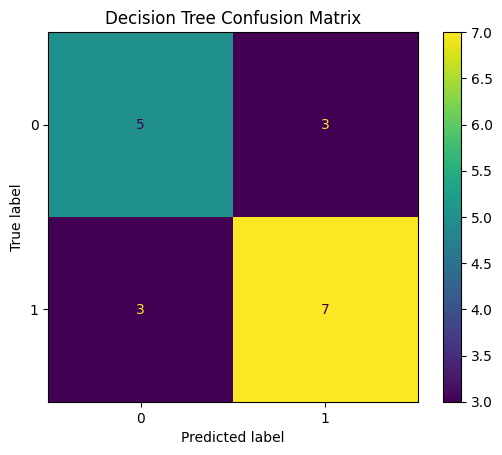

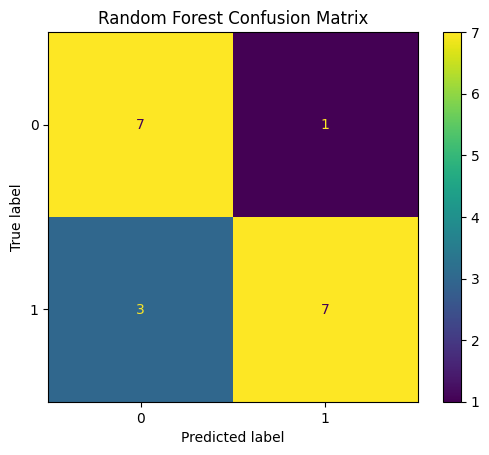


Cross Validation Accuracy:
Decision Tree: 0.5666666666666667
Random Forest: 0.55

 Feature Importance:
        Feature  Importance
3     Humidity    0.383208
2  Temperature    0.208791
1         Soil    0.129244
0      Weather    0.083205
4         Wind    0.059388
6    Crop Type    0.058772
7       Season    0.047697
5   Fertilizer    0.029694


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2
np.random.seed(42)
n_samples=60
data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['dry','moist','wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','cool'],n_samples),
    'Humidity':np.random.choice(['high','medium','low'],n_samples),
    'Wind':np.random.choice(['strong','weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Corn','Rice'],n_samples),
    'Season':np.random.choice(['Summer','Kharif','Rabi'],n_samples),
}
df=pd.DataFrame(data)

#3
def irrigation_rule(row):
 if row['Soil']=='Dry'and row['Weather']!='Rainy':
   return 'Yes'
 elif row['Soil']=='Wet':
   return 'No'
 elif row['Humidity']=='High'and row['Weather']=='Rainy':
   return 'No'
 else:
  return np.random.choice(['Yes','No'])
df['Irrigate']=df.apply(irrigation_rule,axis=1)
print("Sample Dataset:\n",df.head())

#4
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le

#5
X=df.drop('Irrigate',axis=1)
Y=df['Irrigate']

#6
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.3,random_state=42,stratify=Y

)

#7
dt_model=DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train,Y_train)
Y_pred=dt_model.predict(X_test)

#8
rf_model=RandomForestClassifier(n_estimators=20,random_state=42,criterion='entropy')
rf_model.fit(X_train,Y_train)
Y_pred_rf=rf_model.predict(X_test)

#9
df_accuracy=accuracy_score(Y_test,Y_pred)
rf_accuracy=accuracy_score(Y_test,Y_pred_rf)
print("\nAccuracy Comparision:")
print(f"Decision Tree Accuracy:",df_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

#10
cm_dt=confusion_matrix(Y_test,Y_pred,labels=[0,1])
cm_rf=confusion_matrix(Y_test,Y_pred_rf,labels=[0,1])
cm_dt_df=pd.DataFrame(cm_dt,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])
print("\nDecision Tree Confusion Matrix:\n",cm_dt_df)
print("\nRandom Forest Confusion Matrix:\n",cm_rf_df)

#11

ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

#12
dt_cv=cross_val_score(dt_model,X,Y,cv=5)
rf_cv=cross_val_score(rf_model,X,Y,cv=5)
print('\nCross Validation Accuracy:')
print('Decision Tree:',dt_cv.mean())
print('Random Forest:',rf_cv.mean())

#13
importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':dt_model.feature_importances_}).sort_values(by='Importance',ascending=False)
print("\n Feature Importance:\n",importance)